In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

## Example code given: a Python translation of the MATLAB example. It:
   - Loads the three channels for the selected **slice (1–8)** and **data type (good or bad)**.
   - Converts k-space into images using the inverse Fourier transform.
   - Combines the images using root sum of squares and applies brightness compensation.
   - Crops the eye to **128 × 128 pixels** and adjusts contrast.
   - Plots the combined eye image and channel 1’s k-space.

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


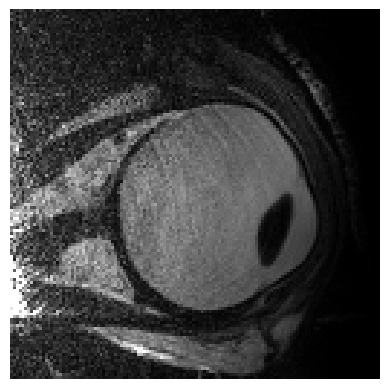

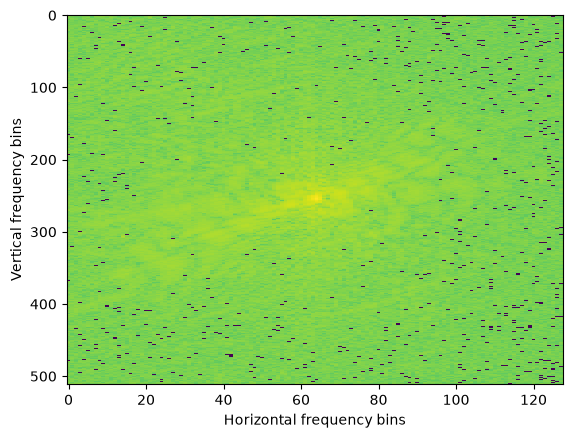

In [8]:
# Example code given

# Script to translate the K-spcae images into spatial eye images

slice_number = 1     # 1 to 8
data_type = "good"   # "good" or "bad"

folder = f"MRI_datasets/Slice{slice_number}/{data_type.capitalize()}Data/"
kspace1 = loadmat(folder + f"slice{slice_number}_channel1.mat")[f"slice{slice_number}_channel1_{data_type}Data"]
kspace2 = loadmat(folder + f"slice{slice_number}_channel2.mat")[f"slice{slice_number}_channel2_{data_type}Data"]
kspace3 = loadmat(folder + f"slice{slice_number}_channel3.mat")[f"slice{slice_number}_channel3_{data_type}Data"]

# 1. X - dimension of the K-Space data    - 128
# 2. Y - dimension of the K-Space data    - 512

# IFFT of k-space data
# channel 1
image1 = np.fft.ifftshift(np.fft.ifft2(kspace1), axes=0)
# channel 2
image2 = np.fft.ifftshift(np.fft.ifft2(kspace2), axes=0)
# channel 3
image3 = np.fft.ifftshift(np.fft.ifft2(kspace3), axes=0)

# clear compensation, preparation, based on fourier transformed blinked
# k-space data (Data_raw)
clear_comp = np.linspace(10, 0.1, image1.shape[1]) ** 2
clear_matrix = np.tile(clear_comp, (image1.shape[0], 1))

# # combine 3 channels sum of squares and add clear compensation
# eye_raw = np.sqrt(np.abs(image1) ** 2 + np.abs(image2) ** 2 + np.abs(image3) ** 2)
# eye_raw = eye_raw * clear_matrix

# crop images because we are only interested in eye. Make it square
# 128 x 128

# Visualize the images.

# image
eye_visualize = eye_raw[187:315, :].copy()  # crop coordinates

# For better visualization and contrast of the eye images, histogram based
# compensation will be done
std_within = 0.995
# set maximum intensity to contain 99.5 % of intensity values per image
bin_centers = np.linspace(0, eye_visualize.max(), 1000)
middle_edges = (bin_centers[:-1] + bin_centers[1:]) / 2
bin_edges = np.concatenate(([-np.inf], middle_edges, [np.inf]))
counts, _ = np.histogram(eye_visualize, bins=bin_edges)
pixel_fraction = np.cumsum(counts) / counts.sum()
first_bin = np.where(pixel_fraction > std_within)[0][0]
thresh = bin_centers[first_bin]

# set threshold value to 65536
eye_visualize = eye_visualize * 65536 / thresh
eye_visualize = np.floor(eye_visualize + 0.5)
eye_visualize = np.clip(eye_visualize, 0, 65535).astype(np.uint16)

# # plotting scripts
# plt.figure()
# plt.imshow(eye_visualize, cmap="gray", interpolation="nearest")
# plt.axis("image")
# plt.axis("off")
# plt.show()

# # Spatial frequency observations
# plt.figure()
# plt.imshow(100 * np.log(np.maximum(np.abs(kspace1), 1e-10)), aspect="auto",
#            interpolation="nearest")
# plt.xlabel("Horizontal frequency bins")
# plt.ylabel("Vertical frequency bins")
# plt.show()

## Good Images (No Outliers)
1. Plot three sub-images as an illustration that fusion is needed

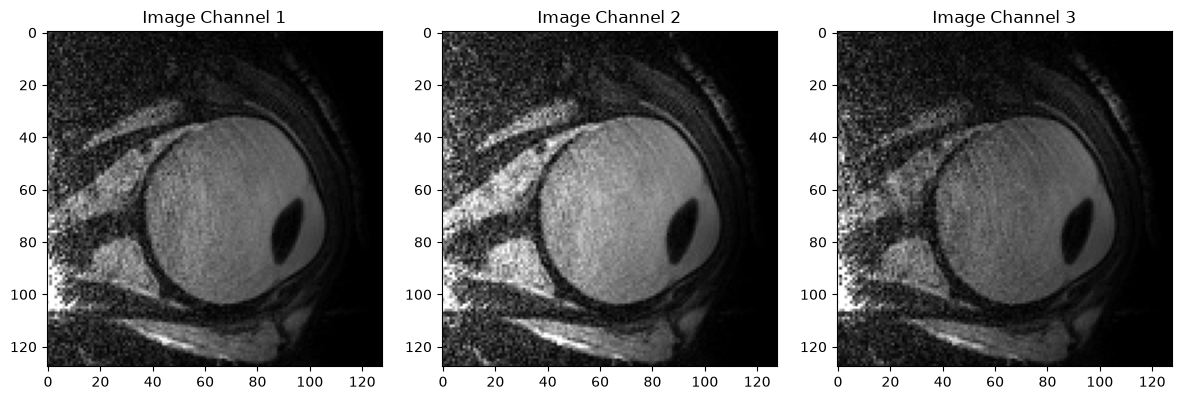

In [34]:
# Get separate images out of the three channels

eye1 = (np.abs(image1) * clear_matrix)[187:315, :]
eye2 = (np.abs(image2) * clear_matrix)[187:315, :]
eye3 = (np.abs(image3) * clear_matrix)[187:315, :]
# Adjust contrast
eye_visualize1 = eye1.copy()
eye_visualize2 = eye2.copy()
eye_visualize3 = eye3.copy()


images = [eye_visualize1, eye_visualize2, eye_visualize3]

for i, eye_visualize in enumerate(images):

    # Using the same contrasting as in the example code
    
    std_within = 0.995
    bin_centers = np.linspace(0, eye_visualize.max(), 1000)
    middle_edges = (bin_centers[:-1] + bin_centers[1:]) / 2
    bin_edges = np.concatenate(([-np.inf], middle_edges, [np.inf]))

    counts, _ = np.histogram(eye_visualize, bins=bin_edges)
    pixel_fraction = np.cumsum(counts) / counts.sum()
    first_bin = np.where(pixel_fraction > std_within)[0][0]
    thresh = bin_centers[first_bin]

    # set threshold value to 65536
    eye_visualize = eye_visualize * 65536 / thresh
    eye_visualize = np.floor(eye_visualize + 0.5)
    images[i] = np.clip(eye_visualize, 0, 65535).astype(np.uint16)

eye_visualize1, eye_visualize2, eye_visualize3 = images

# Plot each channel as an image 
max_value = max(eye_visualize1.max(), eye_visualize2.max(), eye_visualize3.max())

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(eye_visualize1, cmap="gray", vmin=0, vmax=max_value)
plt.title("Image Channel 1")
plt.axis("on")

plt.subplot(1, 3, 2)
plt.imshow(eye_visualize2, cmap="gray", vmin=0, vmax=max_value)
plt.title("Image Channel 2")
plt.axis("on")

plt.subplot(1, 3, 3)
plt.imshow(eye_visualize3, cmap="gray", vmin=0, vmax=max_value)
plt.title("Image Channel 3")
plt.axis("on")

plt.tight_layout()
plt.show()


In [32]:
# Plotting of the full image no contrasting
# plt.figure(figsize=(12, 4))
 
# for i, image in enumerate([image1, image2, image3], start=1):
#       plt.subplot(1, 3, i)
#       plt.imshow(np.abs(image), cmap="gray")
#       plt.title(f"Image {i}")
#       plt.axis("off")
 
# plt.tight_layout()
# plt.show()


2. Estimate the noise variance in the three pictures. We need to measure the variance in the area that seems to not have the eye present.

In [ ]:
row_start, row_end = 0, 20
col_start, col_end = 115, 128
 
background1 = image1[row_start:row_end, col_start:col_end]
background2 = image2[row_start:row_end, col_start:col_end]
background3 = image3[row_start:row_end, col_start:col_end]
 
print("Image 1 noise variance:", np.var(background1, ddof=1))
print("Image 2 noise variance:", np.var(background2, ddof=1))
print("Image 3 noise variance:", np.var(background3, ddof=1))
 
